In [1]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation, Mask2FormerImageProcessor
from PIL import Image
import requests
import torch
import matplotlib.pyplot as plt
import numpy as np
import cv2

from frame_processor import *
from manga_layout import *
from detection import *

In [2]:
image_root = os.path.join(project_root, 'Frame', 'images', 'input')

imgs = [os.path.join(image_root, img) for img in os.listdir(image_root)]

In [3]:
person_segment = PersonSegmenter()

In [4]:
# frames = generate_manga_layout(width = 1000, height = 1400, num_frames=8, seed=42, std_dev=0.05, margin=8, min_ratio=0.3)

# page = create_manga_page(imgs[:8], frames)

# for i, (fx, fy, fw, fh) in enumerate(frames):
#     _,map,_ = human_segmentation(imgs[i])

Loading model from qubvel-hf/finetune-instance-segmentation-ade20k-mini-mask2former...


d:\miniconda3\envs\only_env\lib\site-packages\transformers\utils\deprecation.py:172: UserWarning: The following named arguments are not valid for `Mask2FormerImageProcessor.__init__` and were ignored: '_max_size', '_valid_processor_keys'
  return func(*args, **kwargs)


Dropping instance 0 with low score 0.58


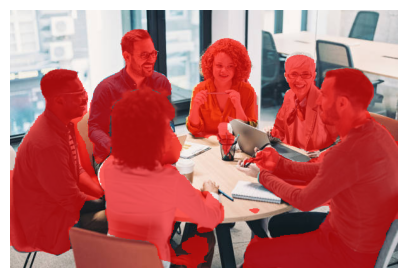

In [5]:
image_np, instance_map, human_mask, result = person_segment.segment(imgs[-2])
overlay = image_np.copy()
alpha = 0.6
red = np.array([255, 0, 0], dtype=np.uint8)

person_ids = [
    seg["id"]
    for seg in result["segments_info"]
    if seg["label_id"] == 0
]

for pid in person_ids:
    mask = instance_map == pid
    overlay[mask] = (
        (1 - alpha) * overlay[mask] + alpha * red
    ).astype(np.uint8)

plt.figure(figsize=(5,5))
plt.imshow(overlay)
plt.axis("off")
plt.show()

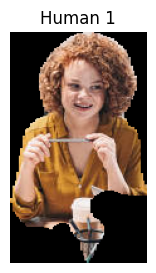

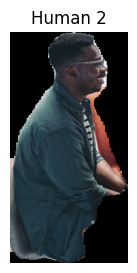

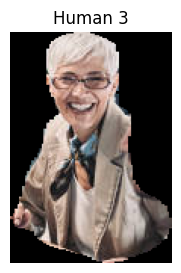

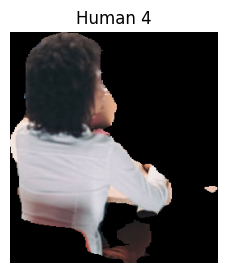

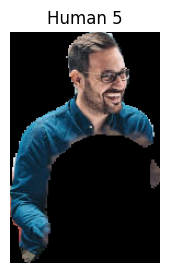

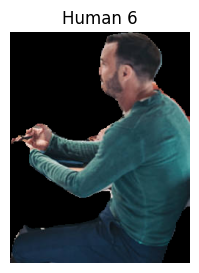

In [ ]:
for i, mask in enumerate(human_mask):
    masked_person = image_np * mask[:, :, np.newaxis]
    
    coords = np.argwhere(mask > 0)
    if coords.size > 0:
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
    
        person_crop = masked_person[y_min : y_max + 1, x_min : x_max + 1]        
        person_img = Image.fromarray(person_crop)

        plt.figure(figsize=(3, 3))
        plt.imshow(person_img)
        plt.title(f"Human {i+1}")
        plt.axis("off")
        plt.show()